In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





In [5]:
df = pd.read_csv('ml.csv')
x = df.iloc[:, : -1].values
y = df.iloc[:, -1].values

In [3]:
df.describe()


,customer_id,age,tenure_months,monthly_charges,total_charges,num_support_tickets,satisfaction_score,churn
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000
mean,500.500000,49.857000,35.19000,69.266890,4187.46378,2.01600,2.980000,0.436000
std,288.819436,18.114267,20.42506,28.793363,2246.67774,1.42821,1.425353,0.496135
min,1.000000,18.000000,1.00000,20.020000,103.50000,0.00000,1.000000,0.000000
25%,250.750000,35.000000,17.00000,43.450000,2280.91000,1.00000,2.000000,0.000000
50%,500.500000,50.000000,35.50000,69.675000,4300.69000,2.00000,3.000000,0.000000
75%,750.250000,66.000000,53.00000,94.597500,6122.58250,3.00000,4.000000,1.000000
max,1000.000000,79.000000,71.00000,119.710000,7997.74000,7.00000,5.000000,1.000000


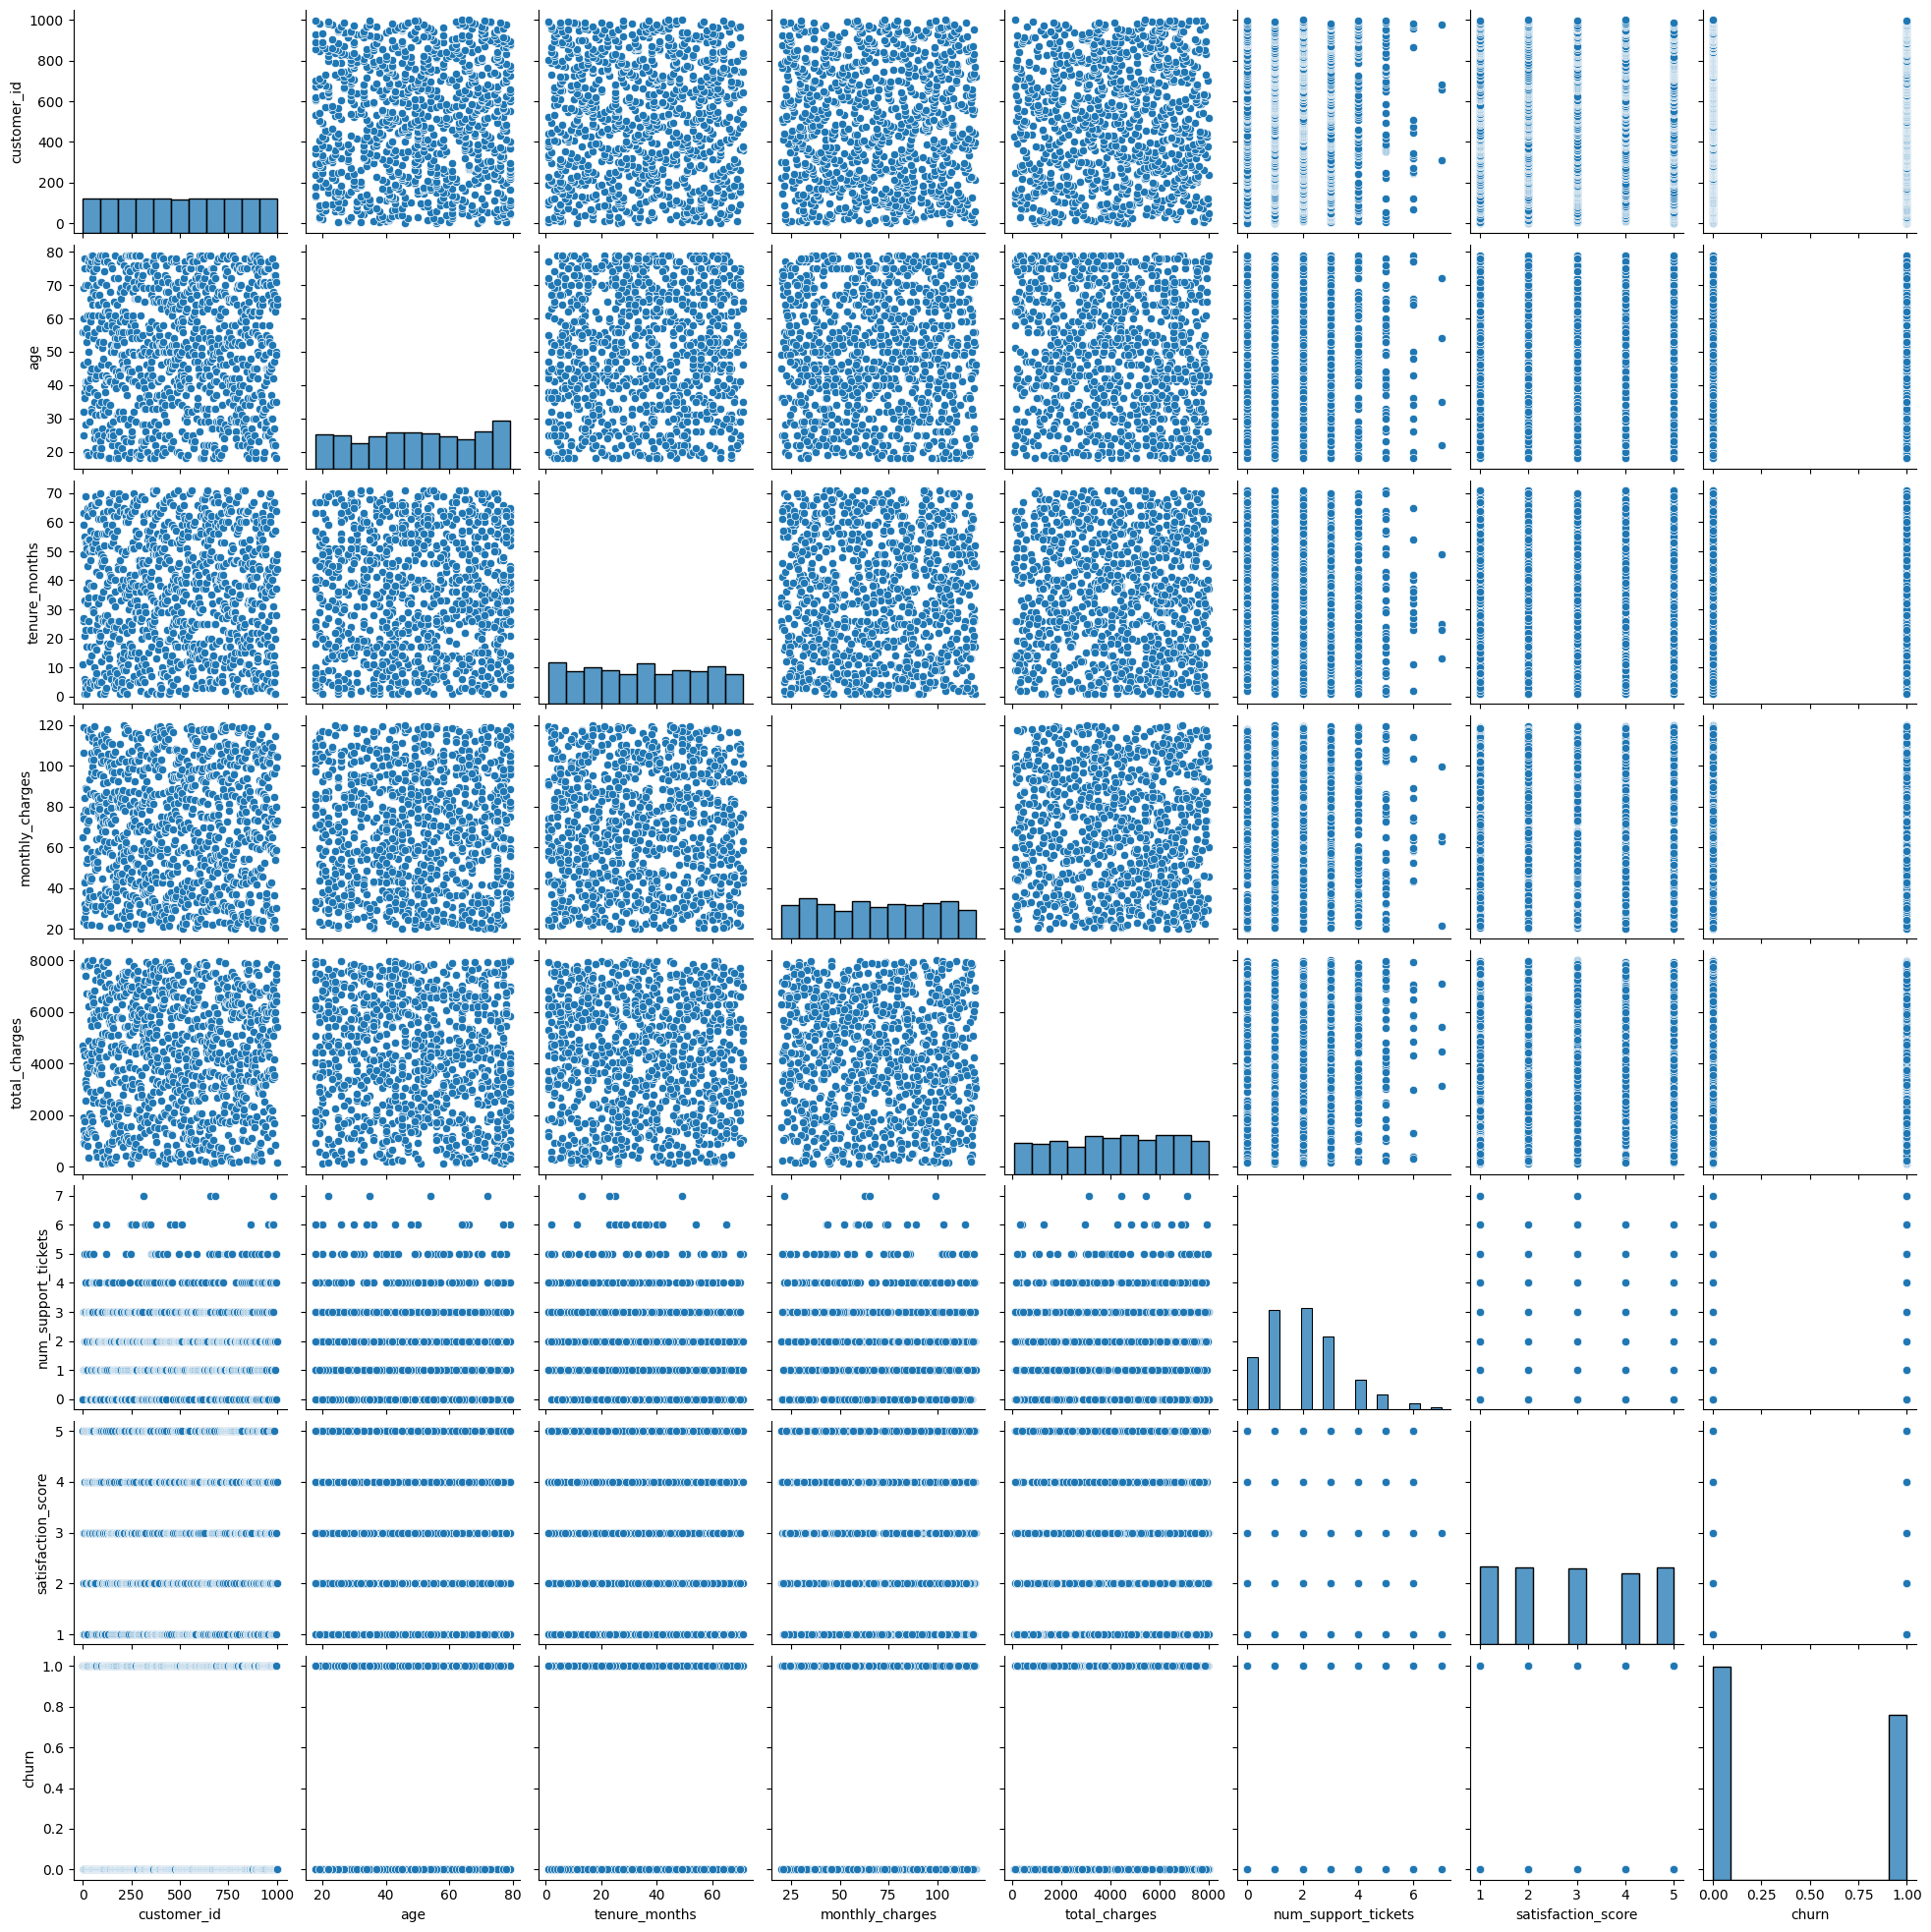

In [6]:
sns.pairplot(df)

<Axes: xlabel='tenure_months', ylabel='total_charges'>

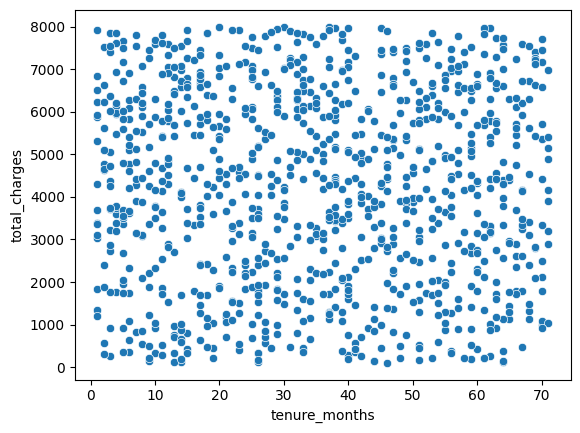

In [10]:
sns.scatterplot(x='tenure_months', y='total_charges', data=df)

In [3]:
df.head()

,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,tech_support,online_security,paperless_billing,num_support_tickets,satisfaction_score,churn
0,1,56,11,64.64,4683.75,Month-to-month,Mailed check,Fiber optic,No,No,No,0,5,1
1,2,69,26,106.42,4521.54,One year,Electronic check,DSL,Yes,No,Yes,1,2,0
2,3,46,63,75.81,931.55,Month-to-month,Bank transfer,Fiber optic,No,No,No,1,1,1
3,4,32,59,73.99,1422.14,Month-to-month,Mailed check,DSL,No,Yes,No,1,2,1
4,5,60,27,23.42,7779.00,Two year,Credit card,DSL,No,Yes,No,1,3,0


In [26]:
print(x)


[[1 56 11 ... 'No' 0 5]
 [2 69 26 ... 'Yes' 1 2]
 [3 46 63 ... 'No' 1 1]
 ...
 [998 49 37 ... 'Yes' 0 3]
 [999 64 49 ... 'No' 2 2]
 [1000 66 44 ... 'No' 2 4]]


In [ ]:
print(y)

In [12]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer
imputer.fit(x[:, -1])
x[:, -1] = imputer.transform(x[:, -1])

AttributeError: 'numpy.ndarray' object has no attribute '_validate_params'

In [31]:

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(x[:, 1:-1])
x[:, 1:-1] = imputer.transform(x[:, 1:-1])
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

ValueError: Cannot use mean strategy with non-numeric data:
could not convert string to float: 'Month-to-month'